In [2]:
import demes
import numpy as np
import moments
import dpluspy

In [4]:
null_graph = "best_fits/null_best_fit.yaml"
null_params = "null_model/params.yaml"

contr_graph = "best_fits/contraction_best_fit.yaml"
contr_params = "contraction_model/params.yaml"

data_file = "../../data/statistics/main/bootstrap_subset_stats.pkl"

pop_ids, bins, means, varcovs, bootreps = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=null_graph, num_reps=100)

u = 1.3e-8
pnames0, params0 = dpluspy.inference._load_params(null_graph, null_params)
model0 = dpluspy.inference.compute_bin_stats(
    null_graph, sampled_demes=pop_ids, u=u, bins=bins)

pnames1, params1 = dpluspy.inference._load_params(contr_graph, contr_params)
model1 = dpluspy.inference.compute_bin_stats(
    contr_graph, sampled_demes=pop_ids, u=u, bins=bins)

In [5]:
ll0 = dpluspy.inference.composite_ll(model0, means, varcovs)
ll1 = dpluspy.inference.composite_ll(model1, means, varcovs)
D_naive = 2 * (ll1 - ll0)
weights = (0, 0.5, 0.5)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)
print(f"D_naive = {D_naive:.3}")
print(f"p_naive = {p_naive:.3}")

D_naive = 11.8
p_naive = 0.00163


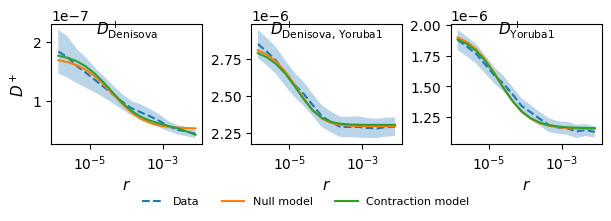

In [7]:
# Plot fits
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1],
    means=means, varcovs=varcovs, bins=bins, pop_ids=pop_ids, 
    labels=["Data", "Null model", "Contraction model"],
    out="figures/fig_best_fits.pdf"
)

In [8]:
print("Pulse model MLE parameters")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

Pulse model MLE parameters
T_split	8.15e+05
N_anc	1.57e+04
N_D0	5.81e+03
N_Y	2.84e+04
T_Dbot	6.91e+04
N_D1	93.8


In [9]:
# Compute adjustment using model 1 fitted parameters
_, __, model1_args = dpluspy.uncerts.set_up_model_args(
    contr_graph, contr_params, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = params1
steps = p_lrt[-2:] * 0.01
nested_idx = np.array([4, 5])

print("Nested parameters and steps:")
print(p_lrt[nested_idx])
print(steps)

print("\nAdjustment parameters")
for name, val in zip(pnames1, p_lrt):
    print(f"{name}\t{val:.3}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model1_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj = {adj:.3}")
print(f"D_adj = {D_adj:.3}")
print(f"p = {p_adj:.3}")

Nested parameters and steps:
[69142.64182136    93.80115541]
[691.42641821   0.93801155]

Adjustment parameters
T_split	8.15e+05
N_anc	1.57e+04
N_D0	5.81e+03
N_Y	2.84e+04
T_Dbot	6.91e+04
N_D1	93.8

adj = 0.118
D_adj = 1.39
p = 0.368
